In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('./Downloads/games.csv')



df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

In [5]:
inutiles = ["About the game", "Reviews", "Website", "Support url", "Support email", 
            "Metacritic url", "Notes", "Score rank", "Movies", "Header image", "Screenshots"]
df = df.drop(columns=inutiles)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   Supported languages         122611 non-null  object 
 9   Full audio languages        122611 non-null  object 
 10  Windows                     122611 non-null  bool   
 11  Mac                         122611 non-null  bool   
 12  Linux                       122611 non-null  bool   
 13  Metacritic s

## Conversion des langages en nombre de langages.

In [6]:
import re

def count_languages(row):
    langs = set()
    for col in ["Supported languages", "Full audio languages"]:
        val = str(row[col])
        # Extraire le contenu entre [ et ]
        matches = re.findall(r'\[([^\]]*)\]', val)
        for match in matches:
            if match.strip():
                # Compter les éléments par les virgules
                items = [x.strip().strip("'") for x in match.split(',')]
                langs.update(items)
    return len(langs)

df["Language Count"] = df.apply(count_languages, axis=1)

## Removing duplicates

We want to remove the **rows** where the Names, Developers and Publishers are the sames because we consider them to be the same game.

We only keep the one with the highest peak CCU.

In [7]:
df.shape

(122611, 29)

In [8]:
df = df.loc[
    df.groupby(['Name', 'Developers', 'Publishers'], dropna=False)['Peak CCU'].idxmax()
]

In [9]:
df.shape

(122476, 29)

# Grouping release years

Il n'y a pas suffisamment de jeux avec comme Release Year < 2013 donc nous décidons de les regrouper en une seule classe. 

In [10]:
years = pd.DatetimeIndex(pd.to_datetime(df["Release date"])).year
df["Year of Release"] = years
df["Year of Release"].value_counts()

Year of Release
2025    24966
2024    20019
2023    14588
2022    12278
2021    11066
2020     8802
2018     7442
2019     7242
2017     5917
2016     4141
2015     2501
2014     1517
2013      464
2012      319
2009      308
2011      252
2010      242
2008      153
2007       85
2026       84
2006       63
2005        7
2004        5
2001        4
2003        3
1997        2
2000        2
1999        2
1998        1
2002        1
Name: count, dtype: int64

In [11]:
df.loc[df["Year of Release"] <= 2013, "Year of Release"] = 2013
df.loc[df["Year of Release"] == 2026, "Year of Release"] = 2025

In [12]:
df["Year of Release"].value_counts().sort_index()

Year of Release
2013     1913
2014     1517
2015     2501
2016     4141
2017     5917
2018     7442
2019     7242
2020     8802
2021    11066
2022    12278
2023    14588
2024    20019
2025    25050
Name: count, dtype: int64

In [13]:
df["Year of Release"] = df["Year of Release"].astype('str')

In [14]:
df = df.drop(columns="Release date")

# Création de la colonne TagGenre

Ici on cherche à combiner les deux colonnes "Tags" et "Genres" car il y a beaucoup de duplicatas.

Les Tags et Genres étant stockés dans un string séparée par des virgules, nous les séparons en différentes colonnes, c'est une forme de one hot encoding.

In [15]:
def merge_and_clean(row):
    tags = str(row['Tags']).split(',') if pd.notna(row['Tags']) else[]
    genres = str(row['Genres']).split(',') if pd.notna(row['Genres']) else[] 
    
    tous_les_mots =[mot.strip() for mot in (tags + genres) if mot.strip()]
    mots_uniques = set(tous_les_mots)
    return ','.join(mots_uniques)
    
df2 = df.copy(deep = True)
combined_series = df2.apply(merge_and_clean, axis=1)
combined_dummies = combined_series.str.get_dummies(sep=',').astype(bool)
combined_dummies.columns =[f"TagGenre_{c}" for c in combined_dummies.columns]
df2 = pd.concat([df2, combined_dummies], axis=1)
print(df2.head())

                                                 Name Estimated owners  \
2556940                                 ! Shakabula *        0 - 20000   
449940   ! That Bastard Is Trying To Steal Our Gold !   50000 - 100000   
1287250                               ! Wild Russia !        0 - 20000   
866510                                       !AnyWay!  100000 - 200000   
870990                                     !LABrpgUP!    20000 - 50000   

         Peak CCU  Required age  Price  Discount  DLC count  \
2556940         0             0  14.99         0          0   
449940          0             0   2.99         0          0   
1287250         0             0  19.99         0          0   
866510          2             0   1.79        10         39   
870990          0             0   0.99         0          0   

                                       Supported languages  \
2556940                                        ['English']   
449940                                         ['Eng

On sépare les colonnes Developers et Publishers car elles possèdent trop de valeurs uniques et donc provoqueraient une explosion du nombre de colonnes lors de leur one hot encoding pour les méthodes de MCA et MFA.

In [16]:
Optionels = ["Developers", "Publishers"]
df2 = df2.drop(columns=Optionels)
df2.info(verbose=all)

<class 'pandas.core.frame.DataFrame'>
Index: 122476 entries, 2556940 to 396420
Data columns (total 479 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    Name                                        object 
 1    Estimated owners                            object 
 2    Peak CCU                                    int64  
 3    Required age                                int64  
 4    Price                                       float64
 5    Discount                                    int64  
 6    DLC count                                   int64  
 7    Supported languages                         object 
 8    Full audio languages                        object 
 9    Windows                                     bool   
 10   Mac                                         bool   
 11   Linux                                       bool   
 12   Metacritic score                            int64  
 13   User score 

In [17]:
Categories_dummies = df2['Categories'].str.get_dummies(sep=',').astype(bool)
Categories_dummies.columns = [f"Categories_{c.strip()}" for c in Categories_dummies.columns] # merci gemini
df2 = pd.concat([df2, Categories_dummies], axis=1)
print(df2.head())

                                                 Name Estimated owners  \
2556940                                 ! Shakabula *        0 - 20000   
449940   ! That Bastard Is Trying To Steal Our Gold !   50000 - 100000   
1287250                               ! Wild Russia !        0 - 20000   
866510                                       !AnyWay!  100000 - 200000   
870990                                     !LABrpgUP!    20000 - 50000   

         Peak CCU  Required age  Price  Discount  DLC count  \
2556940         0             0  14.99         0          0   
449940          0             0   2.99         0          0   
1287250         0             0  19.99         0          0   
866510          2             0   1.79        10         39   
870990          0             0   0.99         0          0   

                                       Supported languages  \
2556940                                        ['English']   
449940                                         ['Eng

# Outliers

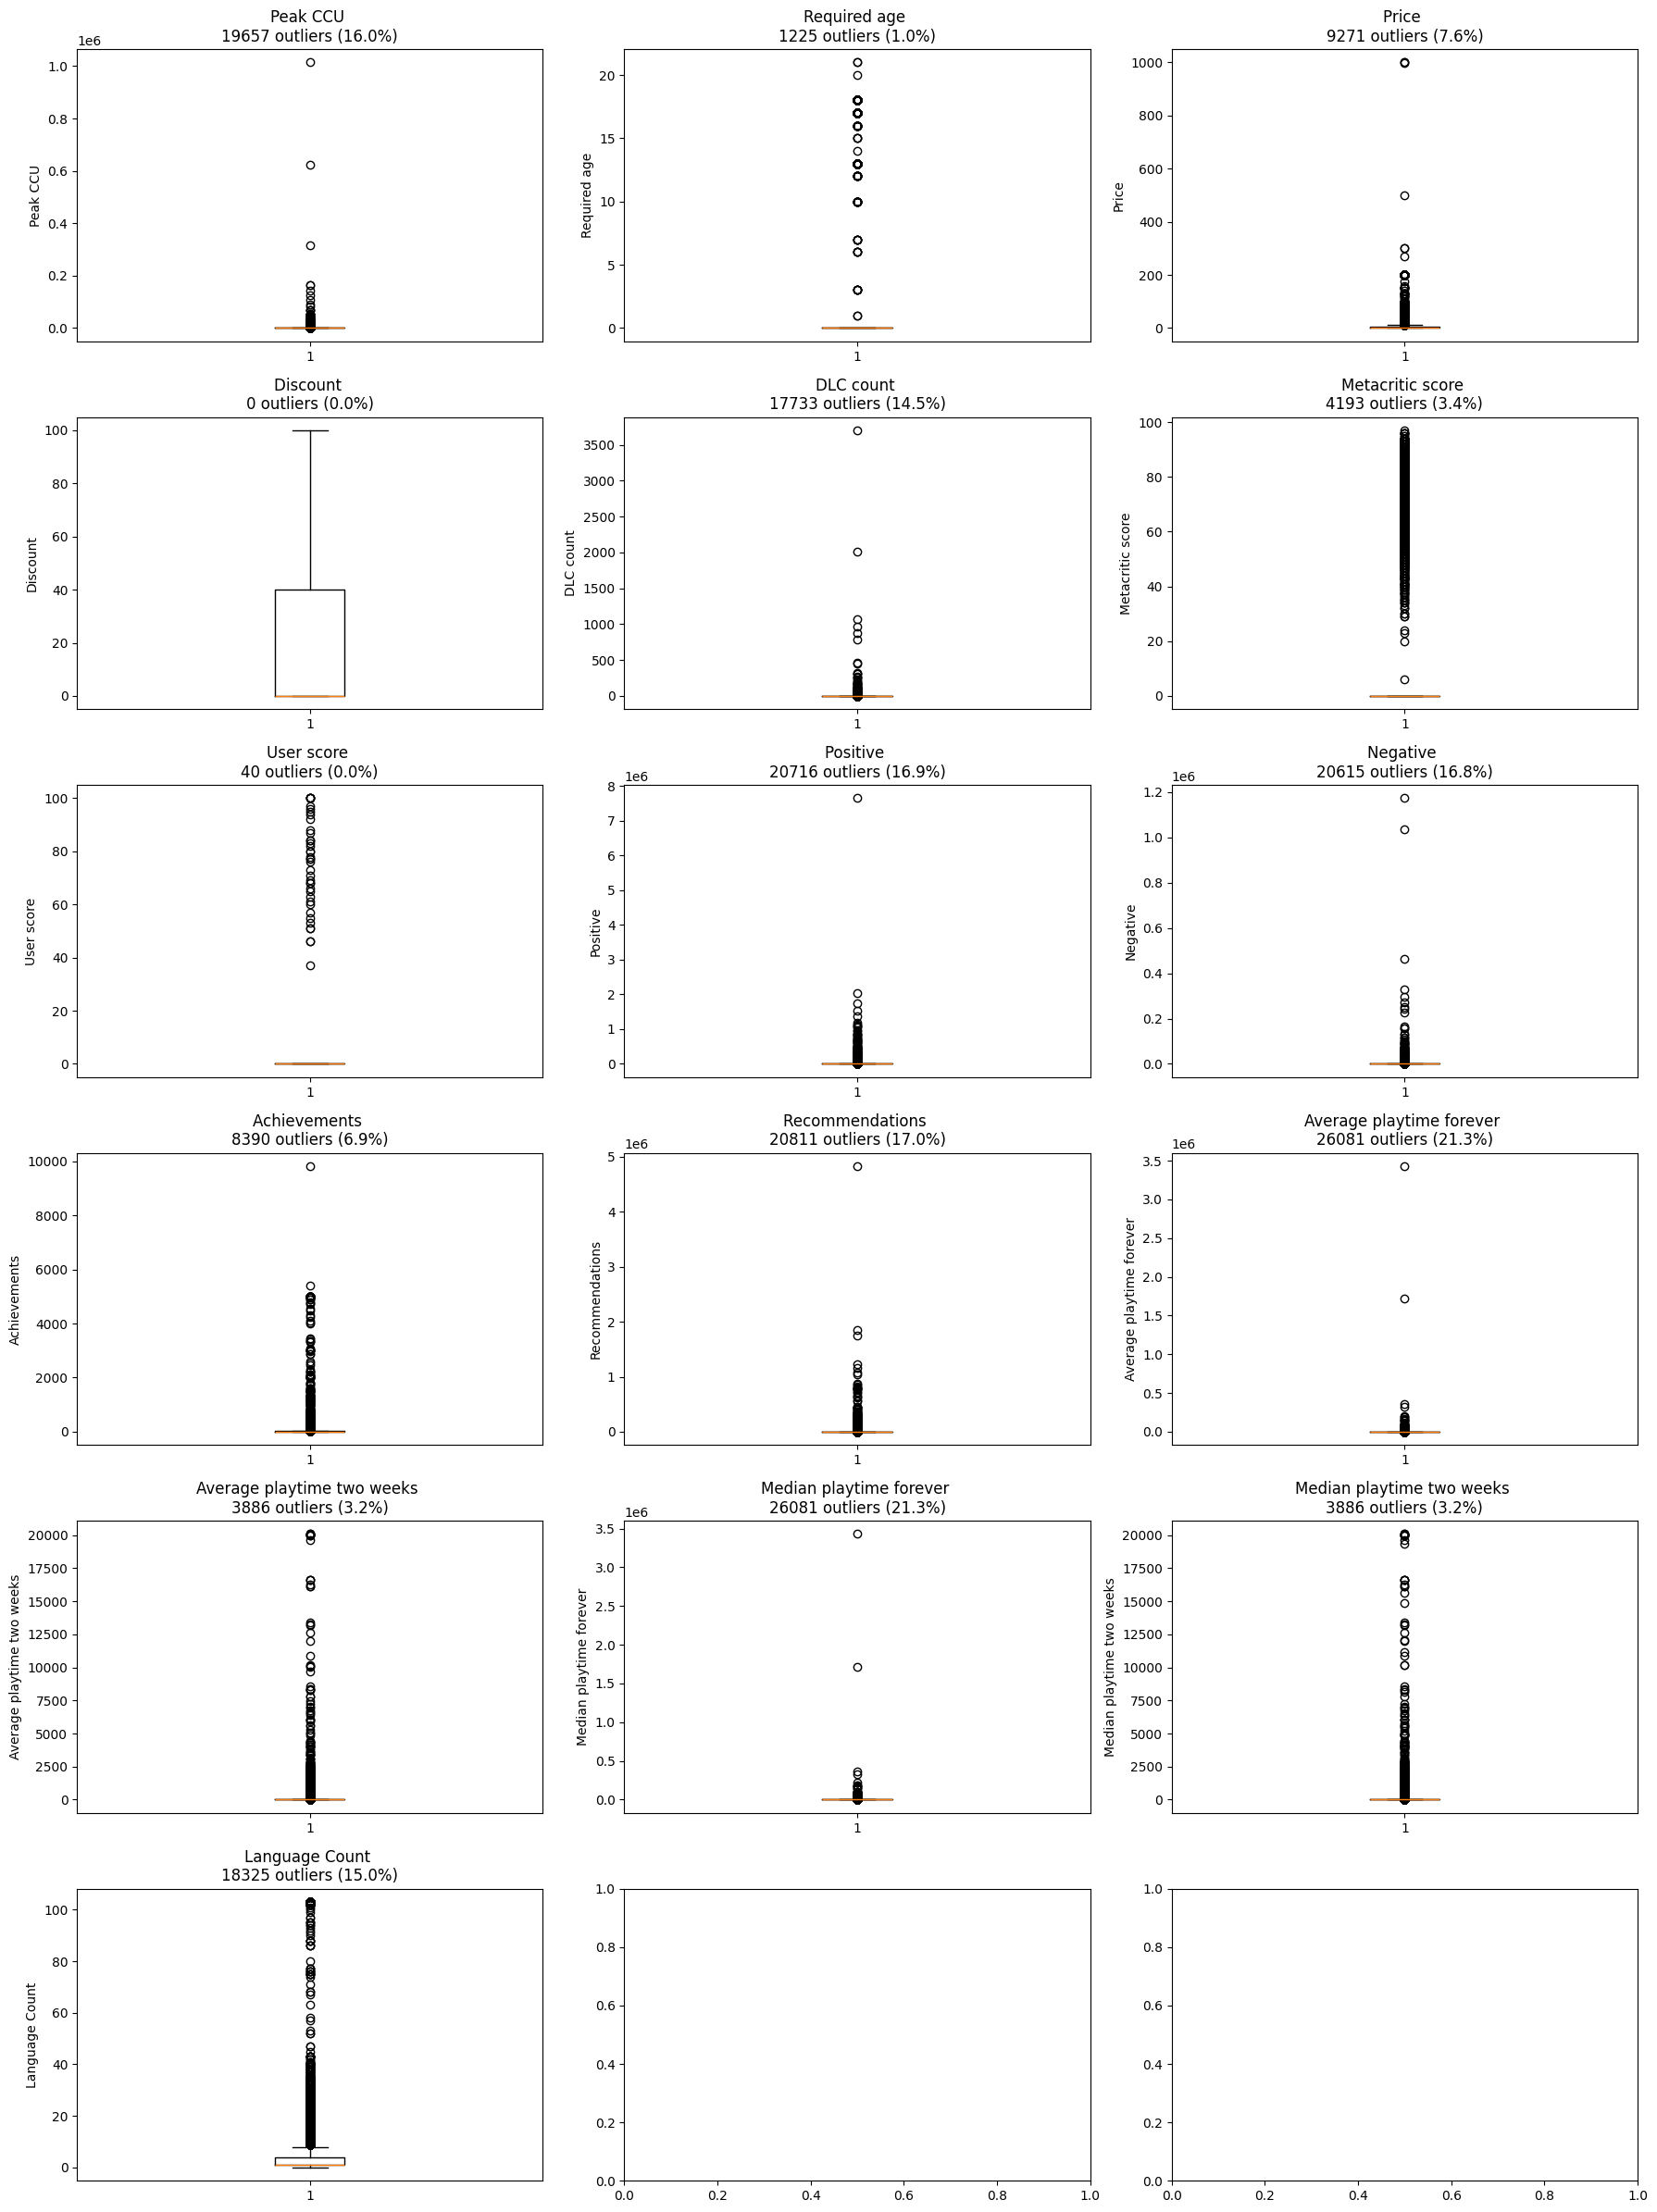


 Outliers par col
                                  n    pct   lower    upper
Average playtime forever    26081.0  21.29   0.000    0.000
Median playtime forever     26081.0  21.29   0.000    0.000
Recommendations             20811.0  16.99   0.000    0.000
Positive                    20716.0  16.91 -55.500   92.500
Negative                    20615.0  16.83 -15.000   25.000
Peak CCU                    19657.0  16.05   0.000    0.000
Language Count              18325.0  14.96  -3.500    8.500
DLC count                   17733.0  14.48   0.000    0.000
Price                        9271.0   7.57  -6.485   12.275
Achievements                 8390.0   6.85 -28.500   47.500
Metacritic score             4193.0   3.42   0.000    0.000
Average playtime two weeks   3886.0   3.17   0.000    0.000
Median playtime two weeks    3886.0   3.17   0.000    0.000
Required age                 1225.0   1.00   0.000    0.000
User score                     40.0   0.03   0.000    0.000
Discount             

In [18]:
import matplotlib.pyplot as plt
def plot_outliers(df, cols, ncols=3):
    # Boxplots et nombre d'outlier pour chaque variable quantitative
    nrows = (len(cols) // ncols)+1          # division plafond
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = axes.flatten()
 
    summary = {}
    for i, col in enumerate(cols):
        serie = df[col]
        Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
        IQR = Q3 - Q1
        mask_outliers = (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)
        n_outliers = mask_outliers.sum()
        pct_outliers = 100 * n_outliers / len(serie)
        summary[col] = {"n": n_outliers, "pct": round(pct_outliers, 2), "lower": Q1 - 1.5 * IQR, "upper": Q3 + 1.5 * IQR}
 
        axes[i].boxplot(serie, vert=True)
        axes[i].set_title(f"{col} \n{n_outliers} outliers ({pct_outliers:.1f}%)")
        axes[i].set_ylabel(col)
 
    plt.tight_layout()
    plt.show()
 
    summary_df = pd.DataFrame(summary).T.sort_values("pct", ascending=False)  # merci claude
    print("\n Outliers par col")
    print(summary_df.to_string())
    return summary_df

NUM_COLS = df2.select_dtypes(include=["number", "int64"])
outlier_summary = plot_outliers(df2, NUM_COLS.columns)

On observe une grande proportion d'outliers sur certaines variables pour différentes raisons :

La majorité des variables ont en fait un trop grand nombre de 0, ce qui force la borne basse et haute de la détection d'outlier à la même valeur : 0.
Cela provoque la détection de toute valeur non nulle comme étant un outlier.

Il est possible de changer le critère d'outlier pour être par exemple : Le 1% des valeurs les plus extrêmes sont des outliers.

Nous pouvons aussi réaliser la même étude uniquement sur les valeurs non nulles.

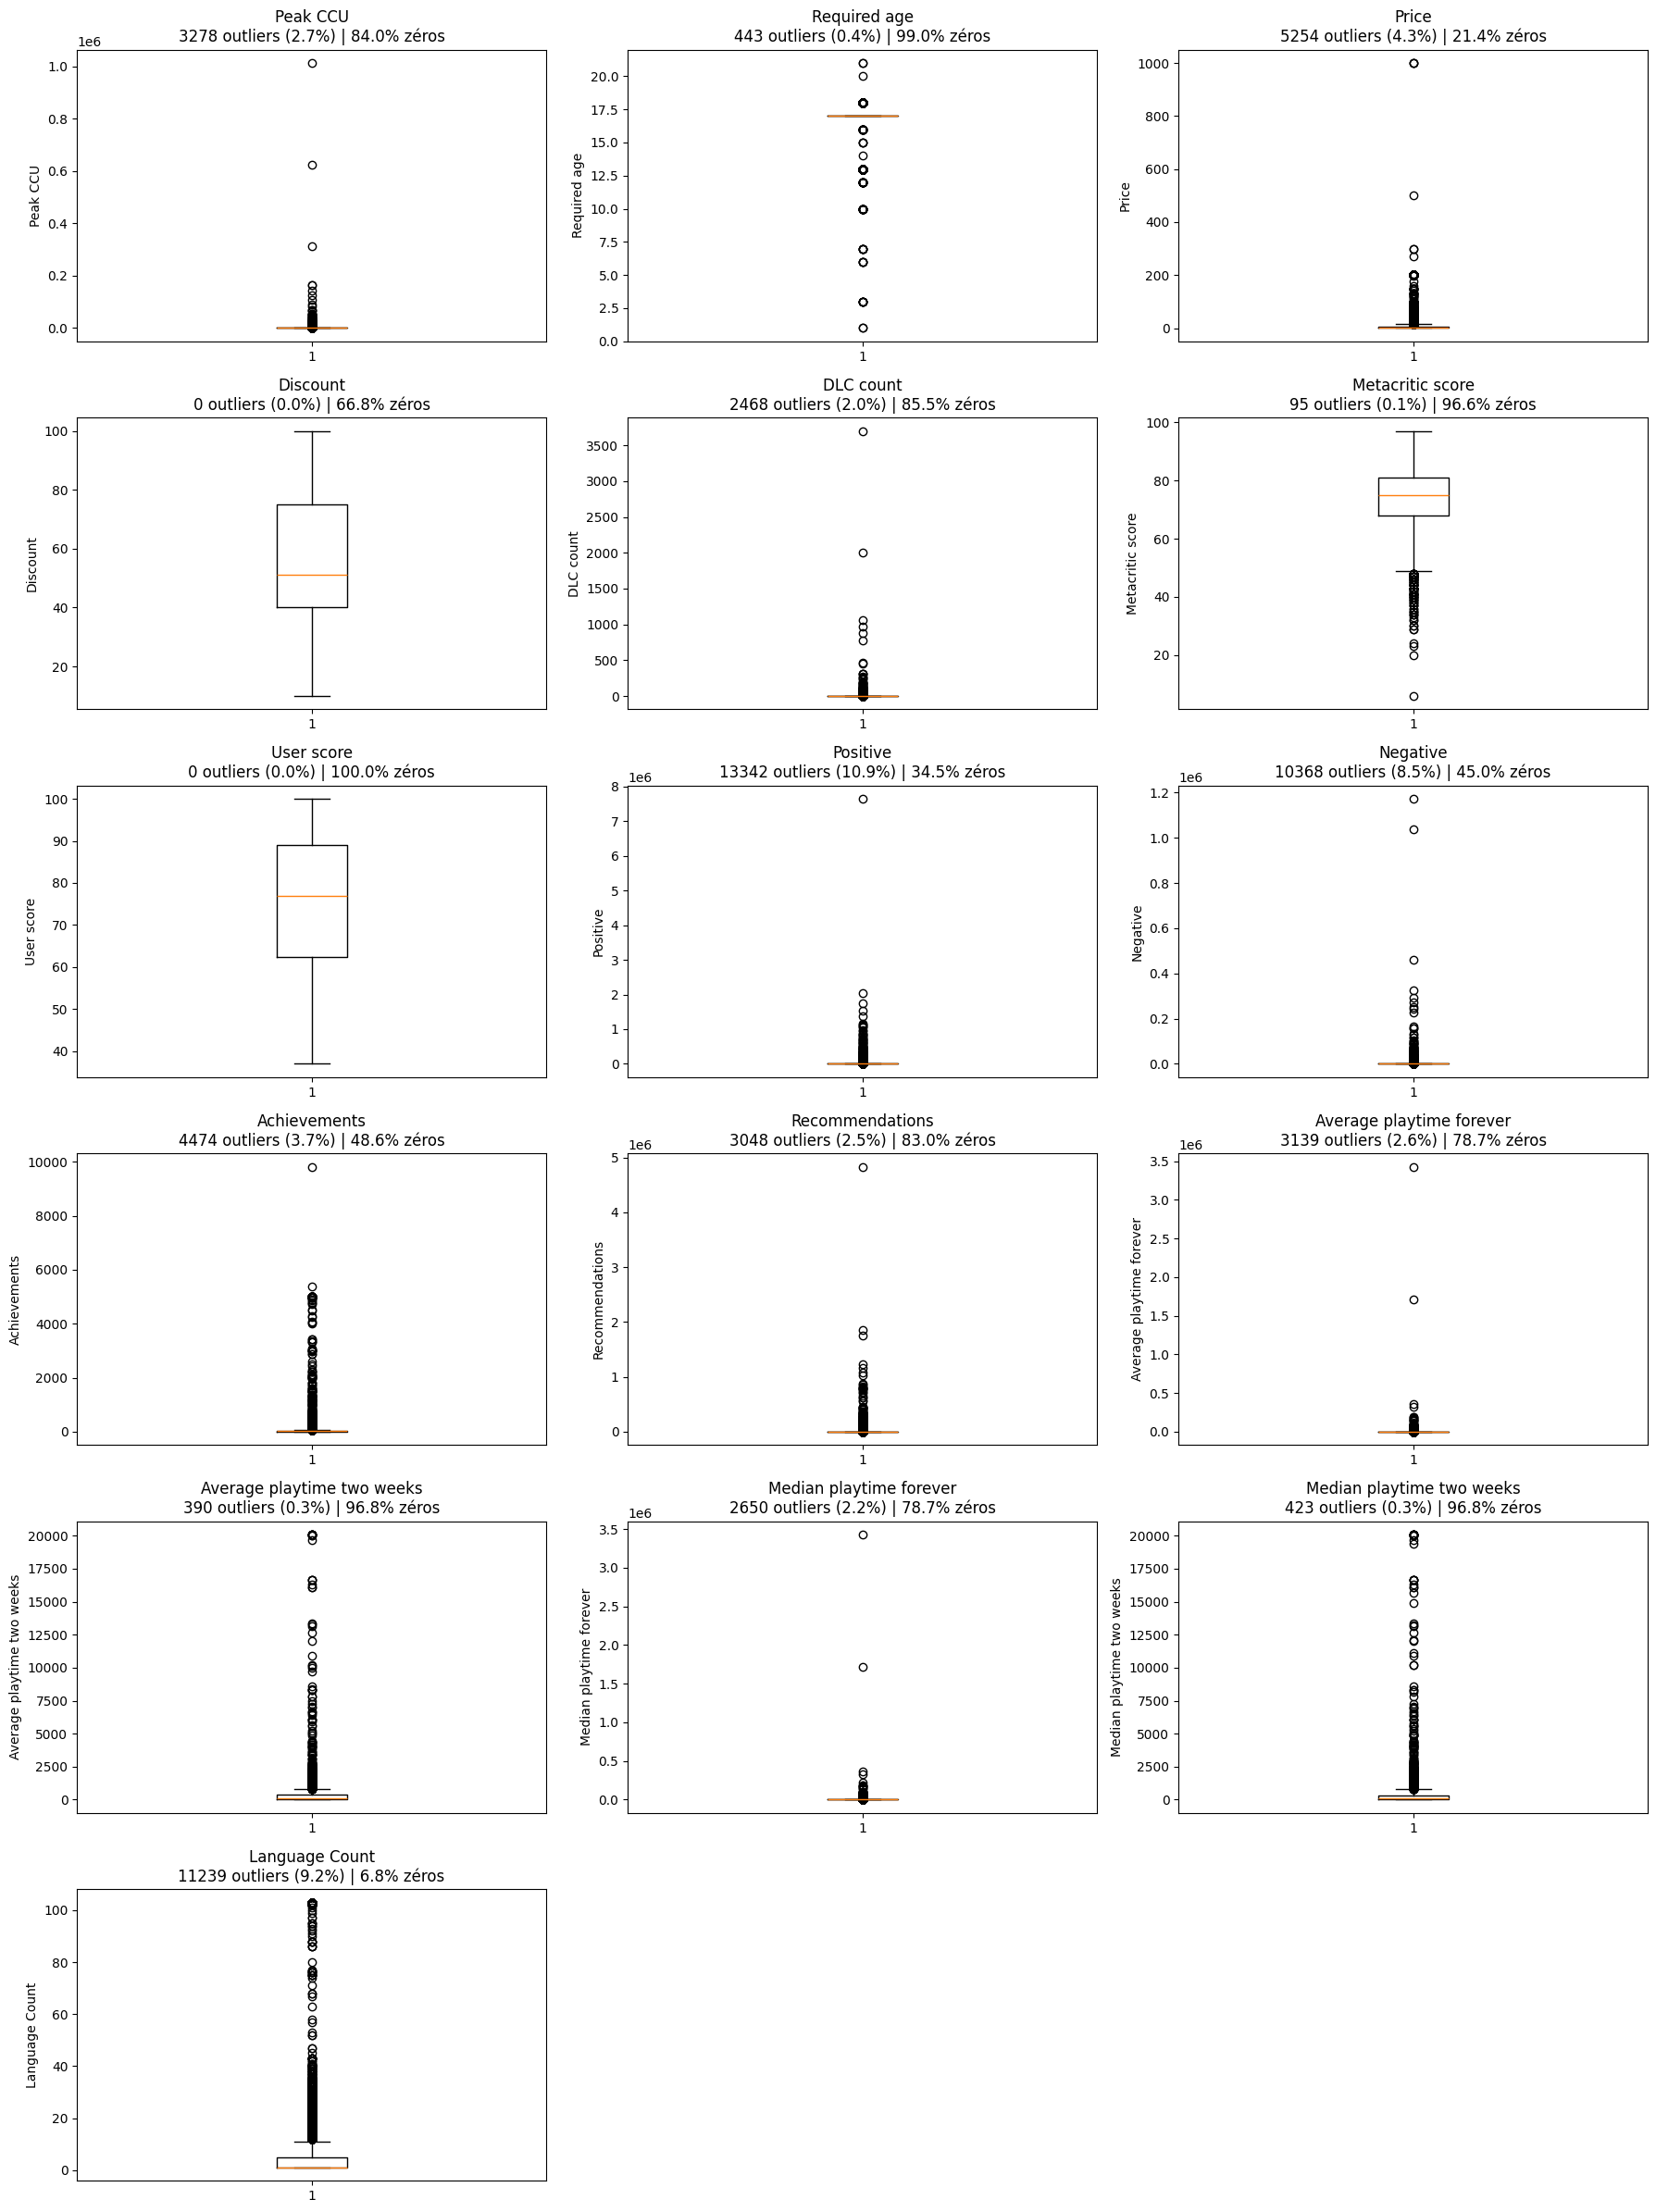


Outliers par colonne
                                  n    pct    lower    upper  pct_zeros
Positive                    13342.0  10.89  -137.50   242.50      34.48
Language Count              11239.0   9.18    -5.00    11.00       6.83
Negative                    10368.0   8.47   -53.50    94.50      45.03
Price                        5254.0   4.29    -6.76    15.24      21.37
Achievements                 4474.0   3.65   -23.00    65.00      48.59
Peak CCU                     3278.0   2.68   -20.00    36.00      83.95
Average playtime forever     3139.0   2.56  -472.00  1016.00      78.71
Recommendations              3048.0   2.49 -1631.00  3209.00      83.01
Median playtime forever      2650.0   2.16  -374.50   837.50      78.71
DLC count                    2468.0   2.02    -0.50     3.50      85.52
Required age                  443.0   0.36    17.00    17.00      99.00
Median playtime two weeks     423.0   0.35  -407.50   780.50      96.83
Average playtime two weeks    390.0   0.32

In [19]:
def plot_outliers_non_nuls(df, cols, ncols=3):
    nrows = (len(cols) // ncols) + 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = axes.flatten()

    summary = {}
    for i, col in enumerate(cols):
        serie = df[col]
        serie_nonzero = serie[serie != 0]  # uniquement les valeurs non-nulles
        
        Q1, Q3 = serie_nonzero.quantile(0.25), serie_nonzero.quantile(0.75)
        IQR = Q3 - Q1
        
        mask_outliers = (serie != 0) & ((serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR))
        n_outliers = mask_outliers.sum()
        pct_outliers = 100 * n_outliers / len(serie)
        pct_zeros = 100 * (serie == 0).sum() / len(serie)
        
        summary[col] = {"n": n_outliers, "pct": round(pct_outliers, 2),
                        "lower": Q1 - 1.5 * IQR, "upper": Q3 + 1.5 * IQR,
                        "pct_zeros": round(pct_zeros, 2)}

        axes[i].boxplot(serie_nonzero, vert=True)  # Boxplot sur les non-zéros
        axes[i].set_title(f"{col}\n{n_outliers} outliers ({pct_outliers:.1f}%) | {pct_zeros:.1f}% zéros")
        axes[i].set_ylabel(col)

    # Masquer les axes inutilisés
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary).T.sort_values("pct", ascending=False)
    print("\nOutliers par colonne")
    print(summary_df.to_string())
    return summary_df

NUM_COLS = df2.select_dtypes(include=["number", "int64"])
outlier_summary = plot_outliers_non_nuls(df2, NUM_COLS.columns)

On décide pour la suite que nous appliquerons des transformations log sur Positive, Negative, Recommandation, et les temps de jeux forever (car les valeurs maximales sont très grandes). 

D'autres transformations seront discutées lors de l'ACP (Peak CCU, Price, Language count et DLC count).

In [20]:
cols_of_interest = [
    "Median playtime forever",
    "Average playtime forever", 
    "Recommendations",
    "Peak CCU",
    "Positive",
    "Negative",
    "DLC count"
]

def get_top_outliers(df, cols, top_n=5):
    for col in cols:
        serie = df[col]
        Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
        IQR = Q3 - Q1
        mask_outliers = (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)
        
        # Récupérer les outliers avec leur nom
        outliers = df[mask_outliers][["Name", col]].copy()
        outliers = outliers.sort_values(col, ascending=False).head(top_n)
        
        print(f"\n{'='*50}")
        print(f"Top {top_n} outliers pour {col}")
        print(f"{'='*50}")
        print(outliers.to_string(index=False))

get_top_outliers(df2, cols_of_interest, top_n=5)


Top 5 outliers pour Median playtime forever
                                      Name  Median playtime forever
                                    Avem33                  3429544
                    iTownGamePlay UNIVERSE                  1714283
Letters From a Rainy Day -Oceans and Lace-                   359674
                                  爱人 Lover                   322983
                           Sisyphus Reborn                   222407

Top 5 outliers pour Average playtime forever
                                      Name  Average playtime forever
                                    Avem33                   3429544
                    iTownGamePlay UNIVERSE                   1714275
Letters From a Rainy Day -Oceans and Lace-                    359665
                                  爱人 Lover                    322983
                                      KAMI                    196736

Top 5 outliers pour Recommendations
                             Name  Recommendations

## Les jeux les plus "détestés"

In [21]:
cols_of_interest = [
    "Positive",
    "Negative",
]
df_temp = df2[["Name","Positive","Negative"]].copy()
df_temp["Negative - Positive"] = (df2["Negative"] - df2["Positive"])
outliers = df_temp.sort_values("Negative - Positive", ascending=False).head(5)
print(f"{'='*50}")
print(outliers.to_string(index=False))

                  Name  Positive  Negative  Negative - Positive
   Mirror 2: Project X     28726     87986                59260
     Battlefield™ 2042    139186    158588                19402
Kerbal Space Program 2      8683     20701                12018
              PAYDAY 3     25497     33195                 7698
         Feed the Cups      3922      9286                 5364


Après quelques recherches, ces jeux sont pour la plupart cibles de "review bombing" pour une raison particulière. Par exemple pour "Kerbal Space Program 2" il s'agit de l'annonce de la fermeture du studio pour raison financière qui a provoqué ces avis. Pour "Mirror 2: Project X" il s'agit d'une protestation des joueurs sur un choix du studio de ne pas intégrer de contenu pour adultes dans le jeu alors que le prequel en contenait.

# Log scallers on some columns

In [22]:
df3 = df2.copy(deep = True)
df3["Positive"] = np.log2(df2["Positive"] + 1)
df3["Negative"] = np.log2(df2["Negative"] + 1)
df3["Recommendations"] = np.log2(df2["Recommendations"] + 1)
df3["Average playtime forever"] = np.log2(df2["Average playtime forever"] + 1)
df3["Median playtime forever"] = np.log2(df2["Median playtime forever"] + 1)

# ACP

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_correlation_circle(pca, feature_names, dim_pairs=None, n_components=None):
    """
    Affiche le cercle des corrélations pour chaque paire de dimensions.
    
    pca : objet PCA fitté
    feature_names : liste des noms de variables (data_pca.columns)
    dim_pairs : liste de tuples (i, j) des paires à afficher. Si None, affiche toutes les paires consécutives.
    n_components : nombre de composantes à considérer (si None, toutes)
    """
    
    # Chargement des corrélations (coordonnées des variables)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    n = n_components or pca.n_components_
    
    # Paires à afficher
    if dim_pairs is None:
        dim_pairs = [(i, i+1) for i in range(0, n-1, 2)]
    
    n_plots = len(dim_pairs)
    ncols = min(3, n_plots)
    nrows = (n_plots + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
    axes = np.array(axes).flatten() if n_plots > 1 else [axes]
    
    for ax, (dim1, dim2) in zip(axes, dim_pairs):
        
        # Cercle unité
        theta = np.linspace(0, 2 * np.pi, 300)
        ax.plot(np.cos(theta), np.sin(theta), color="lightgrey", lw=1.5, ls="--")
        
        # Axes
        ax.axhline(0, color="grey", lw=0.8, ls="--")
        ax.axvline(0, color="grey", lw=0.8, ls="--")
        
        # Flèches + labels des variables
        for i, name in enumerate(feature_names):
            x, y = loadings[i, dim1], loadings[i, dim2]
            ax.annotate(
                "", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue", lw=1.5)
            )
            ax.text(
                x * 1.1, y * 1.1, name,
                fontsize=8, ha="center", va="center", color="darkblue"
            )
        
        # Variance expliquée
        var1 = pca.explained_variance_ratio_[dim1] * 100
        var2 = pca.explained_variance_ratio_[dim2] * 100
        
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
        ax.set_xlabel(f"PC{dim1+1} ({var1:.1f}%)", fontsize=11)
        ax.set_ylabel(f"PC{dim2+1} ({var2:.1f}%)", fontsize=11)
        ax.set_title(f"Cercle des corrélations — PC{dim1+1} et PC{dim2+1}", fontsize=12)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
    
    # Masquer les axes inutilisés
    for ax in axes[n_plots:]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

## Dataset sans les autres log transform

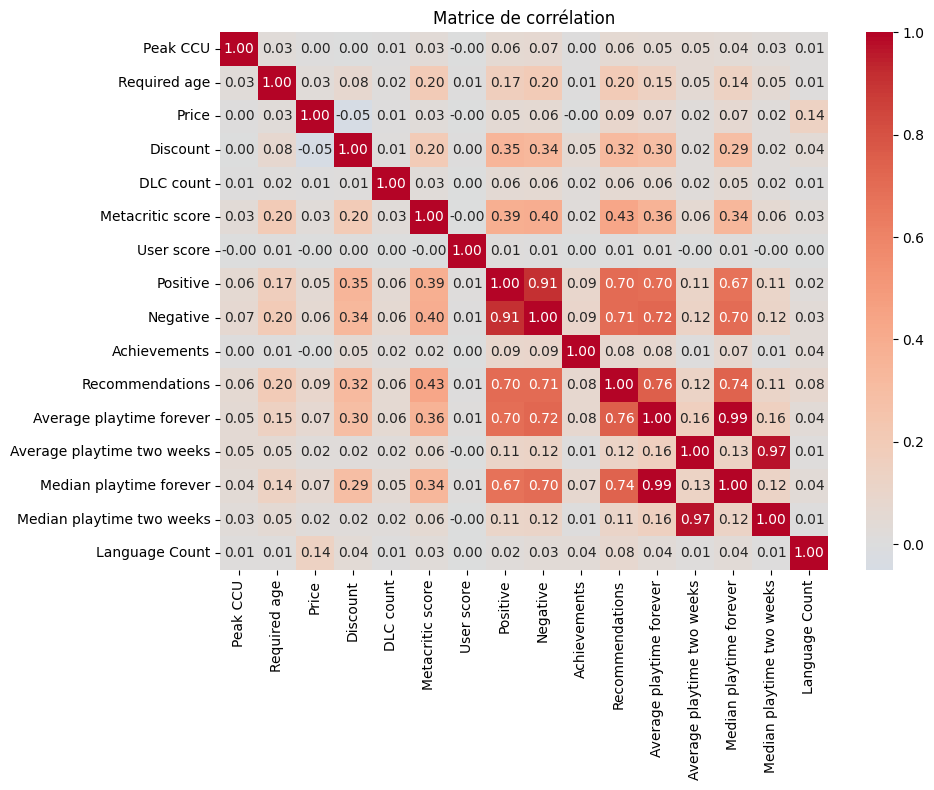

In [25]:
data_pca_2 = df3.select_dtypes(include=["number", "int64"]) #
scaler = StandardScaler()
scaled_df3 = scaler.fit_transform(data_pca_2)
pca_2 = PCA()
pca_df3 = pca_2.fit_transform(scaled_df3) 
explained_variance_2 = pca_2.explained_variance_ratio_

#feature_names = data_pca_2.columns.tolist()
#plot_correlation_circle(pca, feature_names, dim_pairs=[(0,1), (0,2), (1,2)])

corr_matrix = data_pca_2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## Dataset avec les autres log transform sur Peak CCU et DLC count

In [26]:
df3_withOtherLogs = df3.copy(deep = True)
df3_withOtherLogs["Peak CCU"] = np.log2(df3["Peak CCU"] + 1)
df3_withOtherLogs["DLC count"] = np.log2(df3["DLC count"] + 1)
df3_withOtherLogs["Price"] = np.log2(df3["Price"] + 1)
df3_withOtherLogs["Language Count"] = np.log2(df3["Language Count"] + 1)

In [27]:
data_pca = df3_withOtherLogs.select_dtypes(include=["number", "int64"])
scaler = StandardScaler()
scaled_df3 = scaler.fit_transform(data_pca)
pca = PCA()
pca_df3 = pca.fit_transform(scaled_df3) 
explained_variance = pca.explained_variance_ratio_

feature_names = data_pca.columns.tolist()

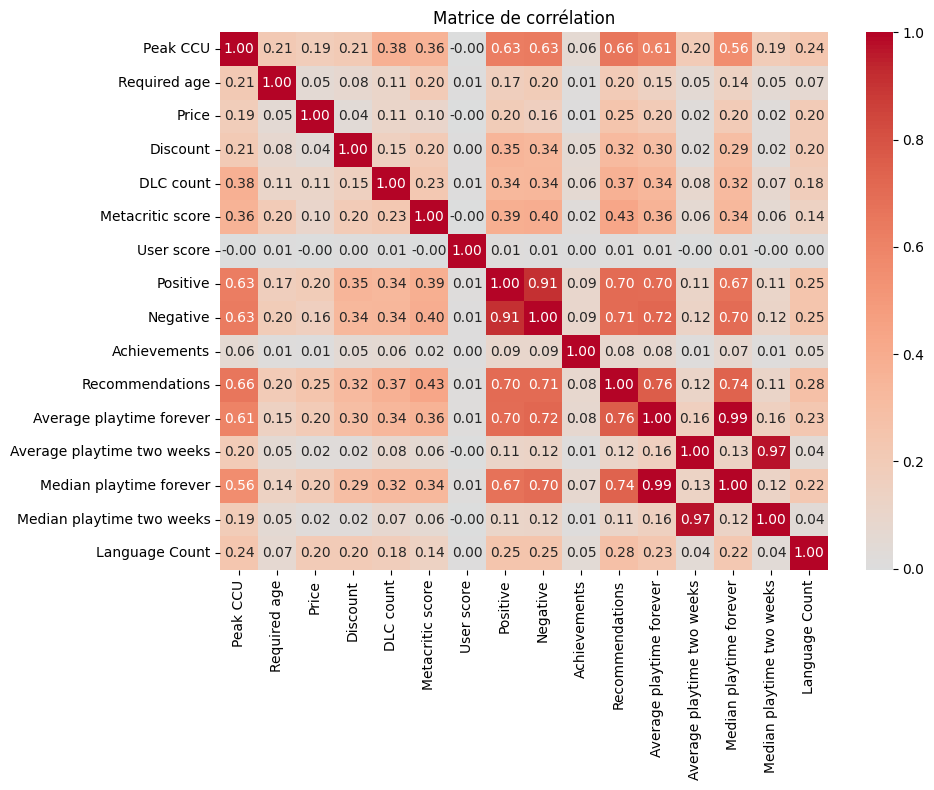

In [28]:
corr_matrix = data_pca.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

Il est intéressant de noter que les corrélations sont très différentes entre les datasets avec/sans log supplémentaires sur **Price**, **Language Count**, **Peak CCU** et **DLC count**.

Ça laisse donc sous-entendre que les liens entre les variables sont probablement assez complexes et pas simplement linéaires ou bien que des valeurs extrêmes bruitent l'ACP sans log.

**Peak CCU**
Le pic de joueurs simultanés est fortement corrélé aux avis positifs/négatifs (0.63), aux recommandations (0.66), au playtime forever (0.60), et dans une moindre mesure au Metacritic score (0.36) et au nombre de DLC (0.37). Un jeu populaire génère donc globalement plus d'engagement sous toutes ses formes.

**Recommendations et temps de jeu**
Le groupe **Recommendations, Average playtime forever, Median playtime forever** forme un cluster très cohérent (corrélations entre 0.74 et 0.99). Les joueurs qui recommandent un jeu y passent aussi beaucoup de temps ce qui est logique : on recommande ce qu'on a vraiment joué.

**Avis positifs et négatifs symétriques**
**Positive** et **Negative** sont corrélés à 0.91. Un jeu très joué accumule mécaniquement beaucoup d'avis dans les deux sens. Ce sont davantage des indicateurs de volume que de qualité.

**Playtime Two weeks**
Les variables **Average** et **Median playtime two weeks** sont très fortement corrélées entre elles (0.97), tout comme leurs équivalents **forever** (0.99). Mais le playtime **two weeks** et le playtime **forever** sont faiblement liés, ce qui suggère que le temps de jeu récent ne reflète pas nécessairement le temps de jeu cumulé sur le long terme. Un jeu ancien très joué peut avoir peu d'activité récente, et inversement.

**Prix et Language Count peu corrélés**
Le prix et le nombre de langages, bien que corrélés à Recommendations, Peak CCU et les Playtime Forever, les corrélations sont très faibles < 0.25.

**Achivements et User Score isolés**
Toutes les corrélations de **User Score** sont proches de 0. Il capte peut-être une dimension qualitative différente du Metacritic score, ou souffre d'un biais de réponse. Il n'y à aucune corrélation notable avec les autres variables.

**Conclusion générale**

Les variables se regroupent en **3 blocs** :
- **Popularité** : Peak CCU, Positive, Negative, Recommendations
- **Engagement** : Average/Median playtime forever, (corrélations > 0.97 entre eux)
- **Variables indépendantes** : Price, User score, Language Count, Achievements

Le Metacritic score et le nombre de DLC semblent jouer un rôle modéré sur la popularité.

## Scree Plot

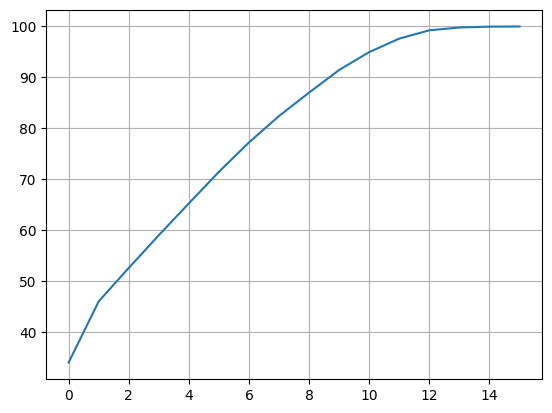

In [29]:
plt.plot(pca.explained_variance_ratio_.cumsum() * 100)
plt.grid()
plt.show()

On observe une réduction de dimension importante : pour conserver 85 % de la variance, il suffit de conserver 9 dimensions au lieu de 15.

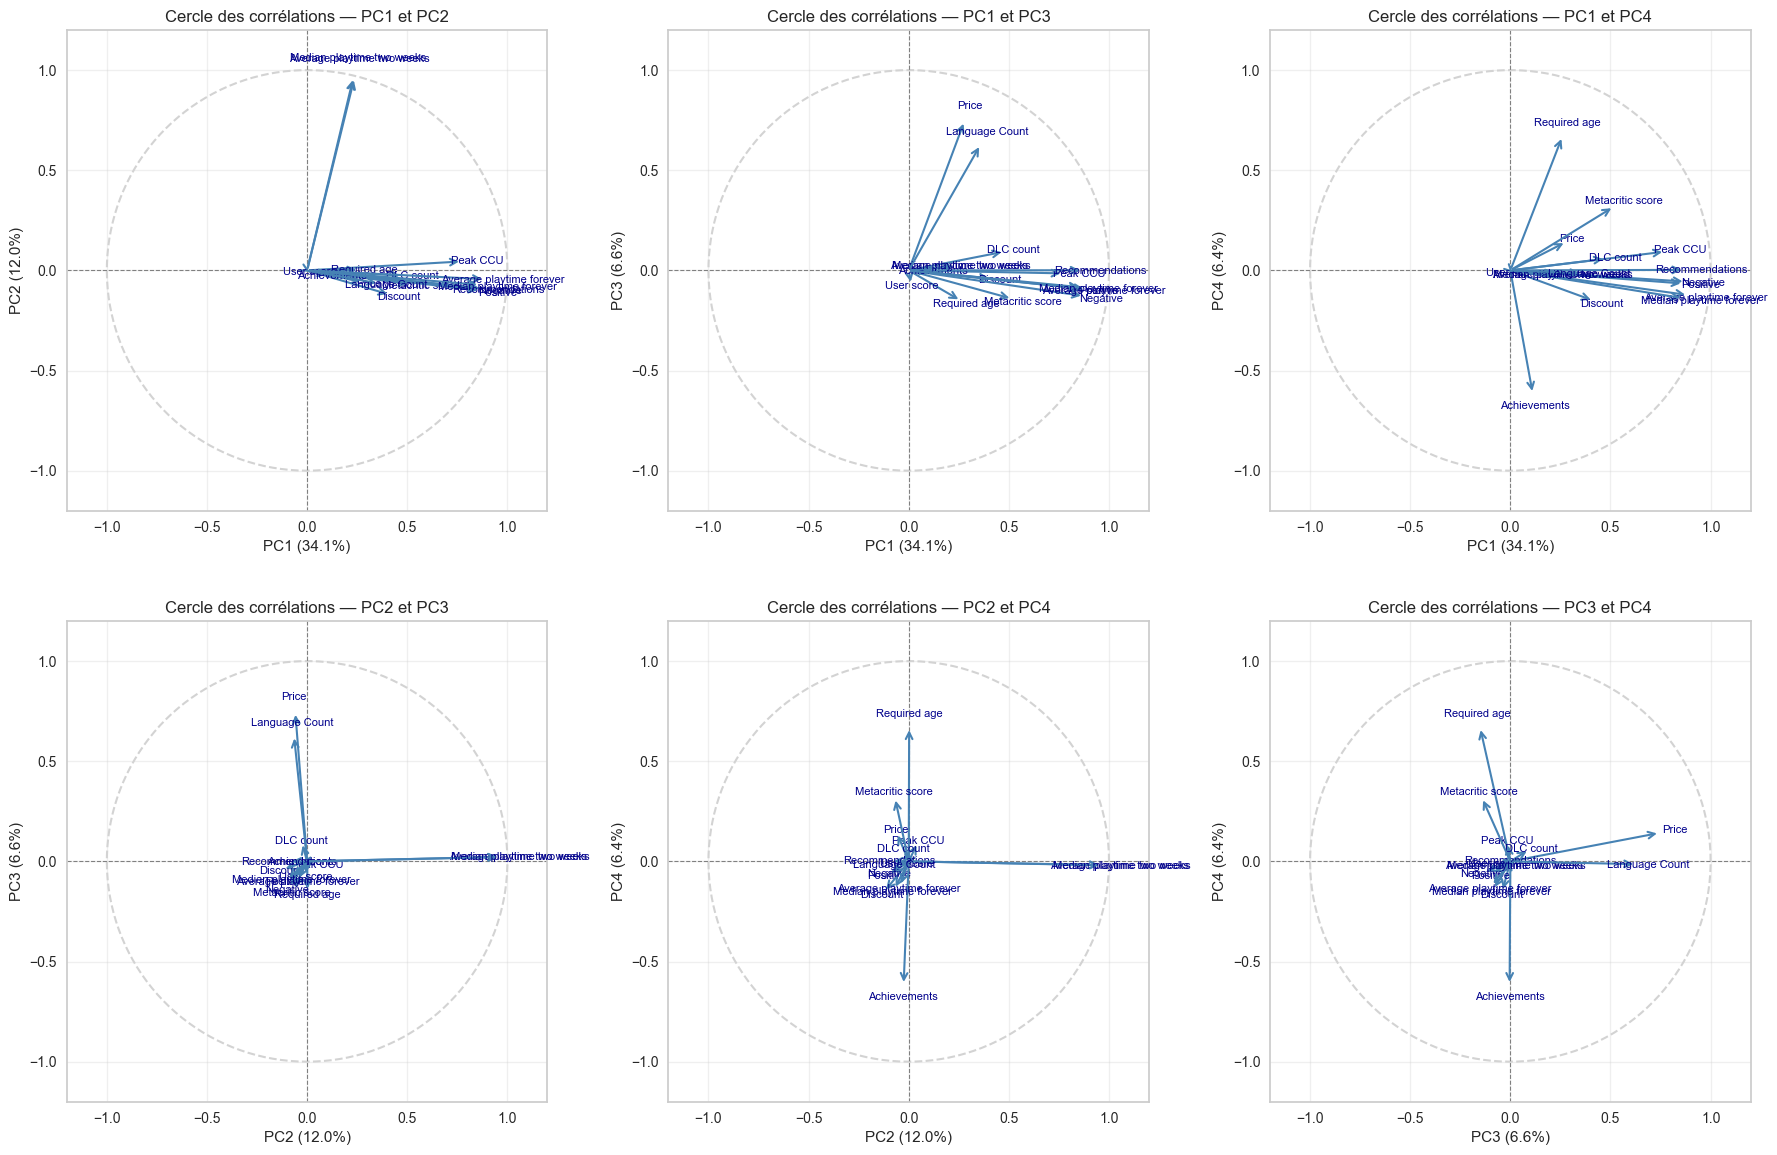

In [153]:
plot_correlation_circle(pca, feature_names, dim_pairs=[(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)])

La PC1 est assez compliquée à lire mais semble encoder l'engagement d'un jeu, avec notamment le **Peak CCU**, les **Recommendations**, les **Playtime forever**. 

La PC2 encode clairement les variables **Playtime two weeks**.

La PC3 semble, elle, indiquer le prix du jeu avec **Price** et **Discount** (Discount n'est pas réellement encodé dans la PC3 mais la contre-corrélation avec **Price** la fait ressortir du lot). Cependant la PC3 n'explique déjà plus que seulement 6.6 % de la variance des données. Il semble que **Achivements** soit aussi légèrement encodé dans la PC3 mais très peu (comme **Discount**)

La PC4 semble à montrer que Required Age et Achievements sont correlé negativement. So the higher the rquired age, the less achievements there are?

### Individuals Factor Map 

In [ ]:
## selecting the first 9 principal components

i = 9
pca_games = pca_df3[:,0:i-1]

expl_var = np.sum(pca.explained_variance_ratio_[:i-1])
print(f"The first {i} PC represent {expl_var*100:.1f}% of the variance")

The first 9 PC represent 82.4% of the variance


The first 6 PC represent 82.4% of the variance


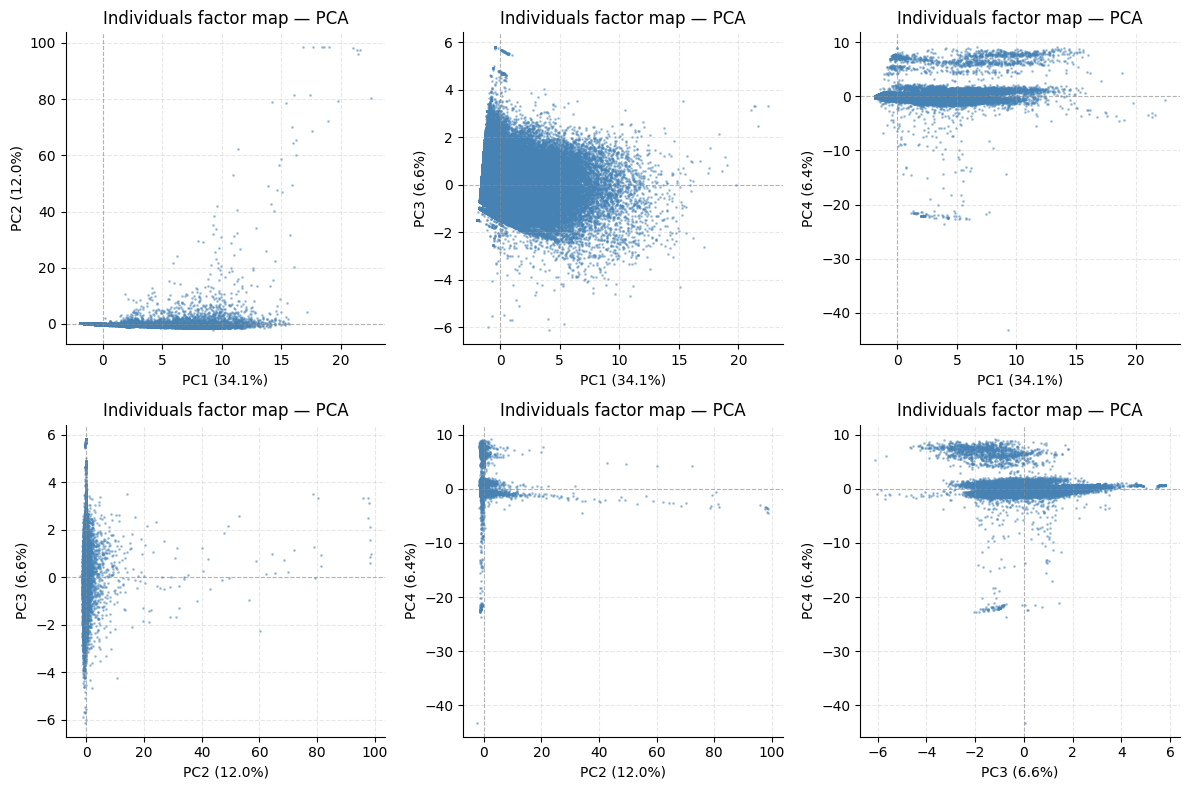

In [ ]:
import matplotlib

fig, axes = plt.subplots(2,3,figsize = (12,8))

pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

for idx, (i,j) in enumerate(pairs):

        ax = axes.flatten()[idx]
        ax.scatter(pca_games[:,i],  pca_games[:,j], s = 1, alpha = 0.4, color = "steelblue")

        ax.set_title("Individuals factor map — PCA")
        ax.set_xlabel(f"PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)")
        ax.set_ylabel(f"PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)")
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Clustering on Individuals

In [154]:
from sklearn.preprocessing import StandardScaler

df_all = df2.copy(deep = True)


df_cluster_copy = df3_withOtherLogs 

raw_games = df3_withOtherLogs.select_dtypes(include=["int64", "number"]) # raw data for k means on raw data

pca_games_scaled = StandardScaler().fit_transform(pca_games) # scaling data for kmeans on scaled data

datasets = [pca_games, pca_games_scaled, raw_games]


### K-means on numerical data

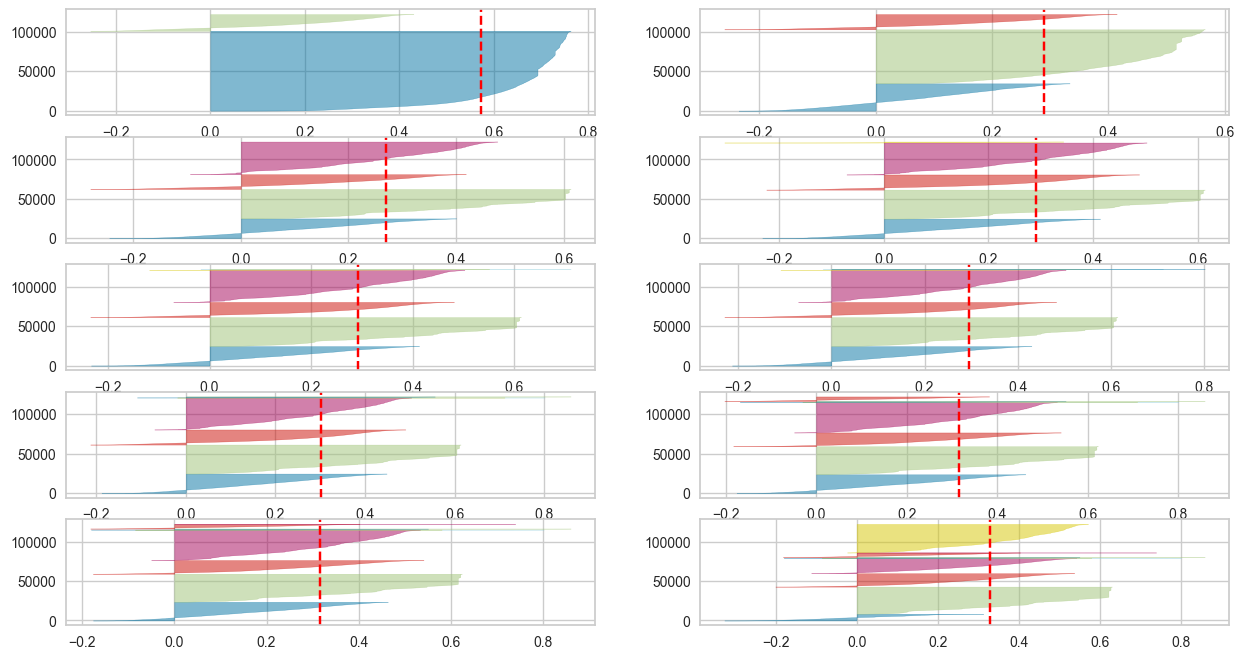

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import colors

from yellowbrick.cluster import SilhouetteVisualizer

#Using the Silhouette Score two find the optimal k number of clusters 

fig, ax = plt.subplots(5, 2, figsize=(15,8))

for k in range(2, 12):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    q, mod = divmod(k, 2)
    
    # Create SilhouetteVisualizer instance with KMeans instance
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax[q-1][mod], force_model=True)
    visualizer.fit(pca_games)

In [ ]:
### k means over pca data

pca_scores = []

for k in range(20, 30):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    labels = kmeans.fit_predict(pca_games)
    
    score = silhouette_score(pca_games, labels)
    pca_scores.append(score)
    print(f"k={k}: {score:.3f}")


k=20: 0.324
k=21: 0.276
k=22: 0.271
k=23: 0.276
k=24: 0.275
k=25: 0.275
k=26: 0.282
k=27: 0.281
k=28: 0.279
k=29: 0.279


In [ ]:
### k means over scaled data

scaled_scores = []

for k in range(2, 30):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    labels = kmeans.fit_predict(pca_games_scaled)
    
    score = silhouette_score(pca_games_scaled, labels)
    scaled_scores.append(score)
    print(f"k={k}: {score:.3f}")

k=2: 0.287
k=3: 0.293
k=4: 0.294
k=5: 0.295
k=6: 0.307
k=7: 0.308
k=8: 0.282
k=9: 0.322
k=10: 0.319
k=11: 0.333
k=12: 0.285
k=13: 0.287
k=14: 0.295
k=15: 0.290
k=16: 0.322
k=17: 0.300
k=18: 0.307
k=19: 0.309
k=20: 0.313
k=21: 0.333
k=22: 0.336
k=23: 0.337
k=24: 0.304
k=25: 0.303
k=26: 0.304
k=27: 0.308
k=28: 0.297
k=29: 0.296


In [ ]:
### k means over raw data 
raw_scores = []
for k in range(2, 30):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=100, random_state=42)
    labels = kmeans.fit_predict(raw_games)
    
    score = silhouette_score(raw_games, labels)
    raw_scores.append(score)
    print(f"k={k}: {score:.3f}")

k=2: 0.996
k=3: 0.982
k=4: 0.983
k=5: 0.967
k=6: 0.961
k=7: 0.945
k=8: 0.920
k=9: 0.587
k=10: 0.591
k=11: 0.591
k=12: 0.595
k=13: 0.595
k=14: 0.595
k=15: 0.595
k=16: 0.599
k=17: 0.624
k=18: 0.624
k=19: 0.626
k=20: 0.626
k=21: 0.624
k=22: 0.624
k=23: 0.625
k=24: 0.626
k=25: 0.626
k=26: 0.626
k=27: 0.625
k=28: 0.551
k=29: 0.512


Results of the Silhouette Scores for K in range [2,30] ( it takes a really long time to calculate)

k=2: 0.572
k=3: 0.290
k=4: 0.271
k=5: 0.292
k=6: 0.293
k=7: 0.296
k=8: 0.302
k=9: 0.315
k=10: 0.316
k=11: 0.329 ### this is the highsest ###
k=12: 0.322
k=13: 0.318
k=14: 0.319
k=15: 0.322
k=16: 0.322
k=17: 0.323
k=18: 0.322
k=19: 0.322
k=20: 0.324 ##### see the drop here ### 
k=21: 0.276
k=22: 0.271
k=23: 0.276
k=24: 0.275
k=25: 0.275
k=26: 0.282
k=27: 0.281
k=28: 0.279
k=29: 0.279

So we will be looking at Kmeans clustering results for K ∈ {2, 11, 20}

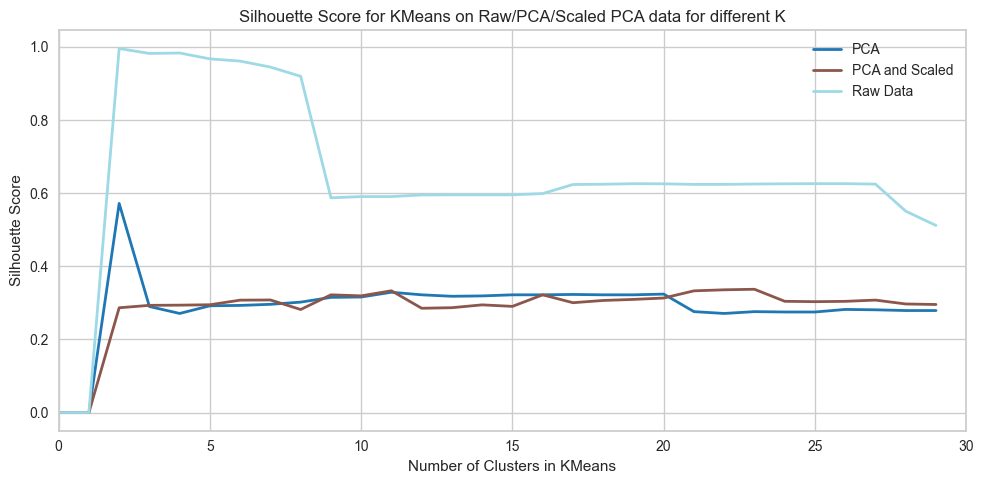

In [150]:
cmap = plt.get_cmap("tab20",3)

pca_scores = np.array([ 0.572, 0.290, 0.271, 0.292, 0.293, 0.296, 0.302, 0.315, 0.316, 0.329, 
                   0.322, 0.318, 0.319, 0.322, 0.322, 0.323, 0.322, 0.322, 0.324, 0.276, 
                   0.271, 0.276, 0.275, 0.275, 0.282, 0.281, 0.279, 0.279])
x = np.arange(30)

sil_scores = np.zeros((3,30))
sil_scores[0,2:30] = pca_scores
sil_scores[1,2:30] = scaled_scores
sil_scores[2,2:30] = raw_scores

descr = ["PCA", "PCA and Scaled", "Raw Data"]

fig, ax = plt.subplots(figsize = (10,5))

for i in range(3):
    ax.plot(x,sil_scores[i,:],color = cmap.colors[i], linewidth=2, label = descr[i])

ax.set_xlabel("Number of Clusters in KMeans")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score for KMeans on Raw/PCA/Scaled PCA data for different K")
ax.set_xlim(0,30)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
cl_sizes = [2,11,20]

datasets = [pca_games, pca_games_scaled, raw_games]

cluster_partiotions = np.zeros((df.shape[0],9))

i = 0

for data in datasets: 

    for K in cl_sizes: 

        kmeans_games = KMeans(n_clusters=K, init="k-means++", n_init="auto", random_state = 42)
        cluster_partiotions[:,i] = kmeans_games.fit_predict(data)

        i+=1

In [ ]:
pca_datasets = [x for x in datasets[0:2] for _ in range(3)]

print(datasets)

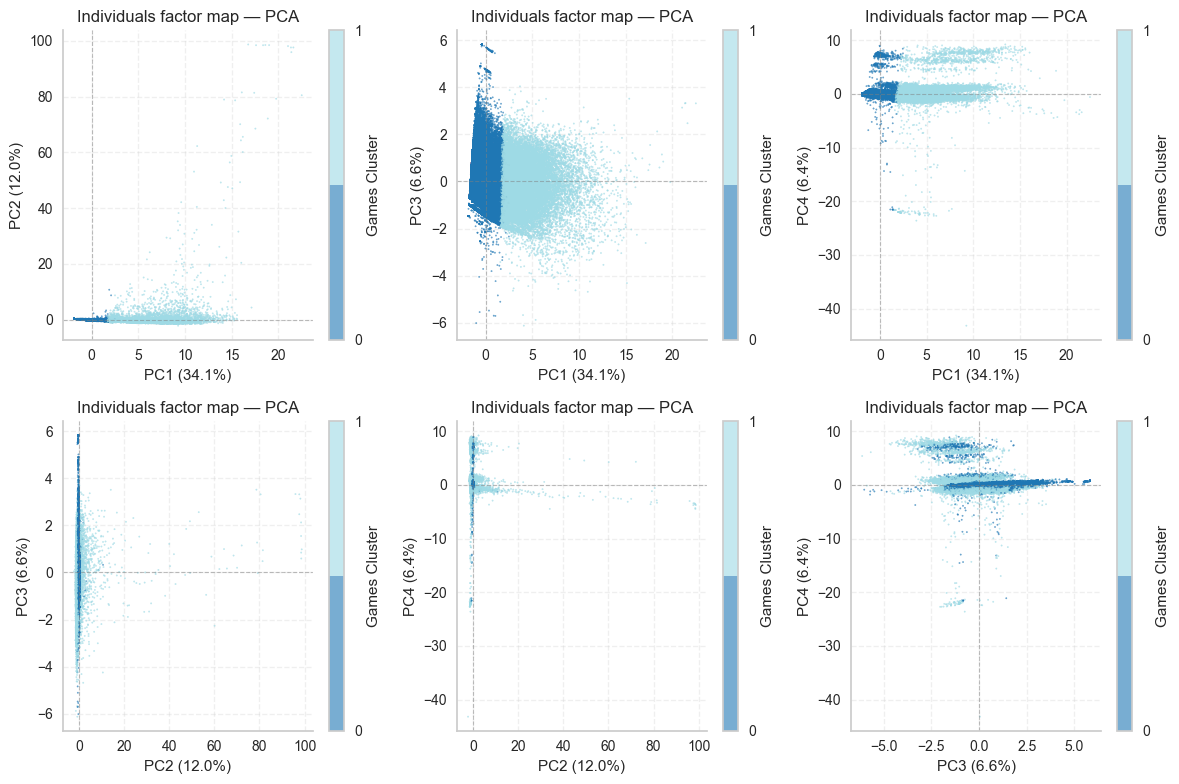

In [ ]:
### Plotting the 6 PCA Partitions for three different Ks and the 2 different data types 

pca_cluster_partitions = cluster_partiotions[:,0:6].T
pca_datasets = [x for x in datasets[0:2] for _ in range(3)]

fig, axes = plt.subplots(12,3,figsize = (12,24))

pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

for index, (data,partition) in enumerate(zip(pca_datasets,pca_cluster_partitions)):

        K = cl_sizes[index%3]

        cmap = plt.get_cmap('tab20',K)

        for idx, (i,j) in enumerate(pairs):
                
                ax = axes.flatten()[6 * index +idx]
                sc = ax.scatter(data[:,i],  data[:,j], c = partition, s = 1, alpha = 0.6, cmap = cmap)

                ax.set_title(f"Individuals factor map — PCA - K={K}")
                ax.set_xlabel(f"PC{i+1}")
                ax.set_ylabel(f"PC{j+1}")
                ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
                ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
                ax.spines[["top", "right"]].set_visible(False)
                ax.grid(True, linestyle="--", alpha=0.3)

                fig.colorbar(sc, ax=ax, ticks=range(K), label= "Games Cluster")

plt.tight_layout()
plt.show()

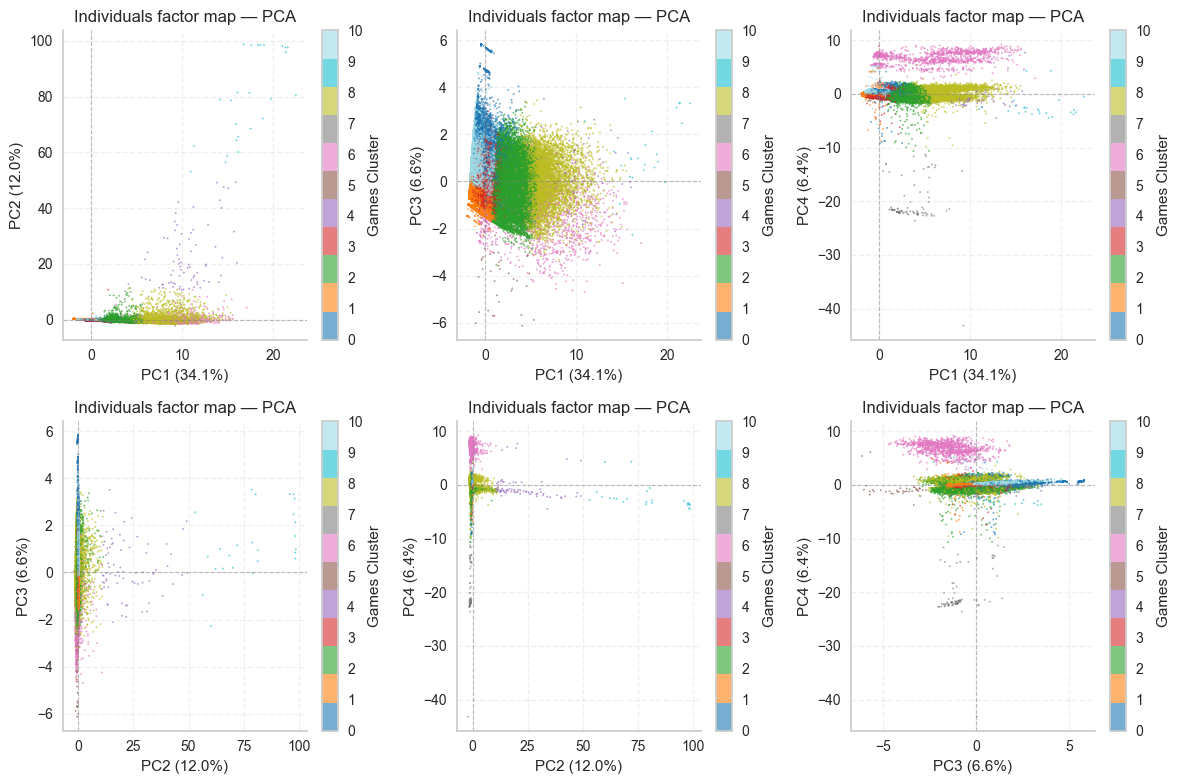

In [84]:
## more Clusters, even though this does not have an optimal silhouette score

K = 11
cmap = plt.get_cmap('tab20',K)

kmeans_games = KMeans(n_clusters=K, init="k-means++", n_init="auto", random_state = 42)
game_clusters[:,1] = kmeans_games.fit_predict(pca_games)

fig, axes = plt.subplots(2,3,figsize = (12,8))

pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

for idx, (i,j) in enumerate(pairs):

        ax = axes.flatten()[idx]
        sc = ax.scatter(pca_games[:,i],  pca_games[:,j], c = game_clusters[:,1], s = 1, alpha = 0.6, cmap = cmap)

        ax.set_title("Individuals factor map — PCA")
        ax.set_xlabel(f"PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)")
        ax.set_ylabel(f"PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)")
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, linestyle="--", alpha=0.3)

        fig.colorbar(sc, ax=ax, ticks=range(K), label= "Games Cluster")

plt.tight_layout()
plt.show()

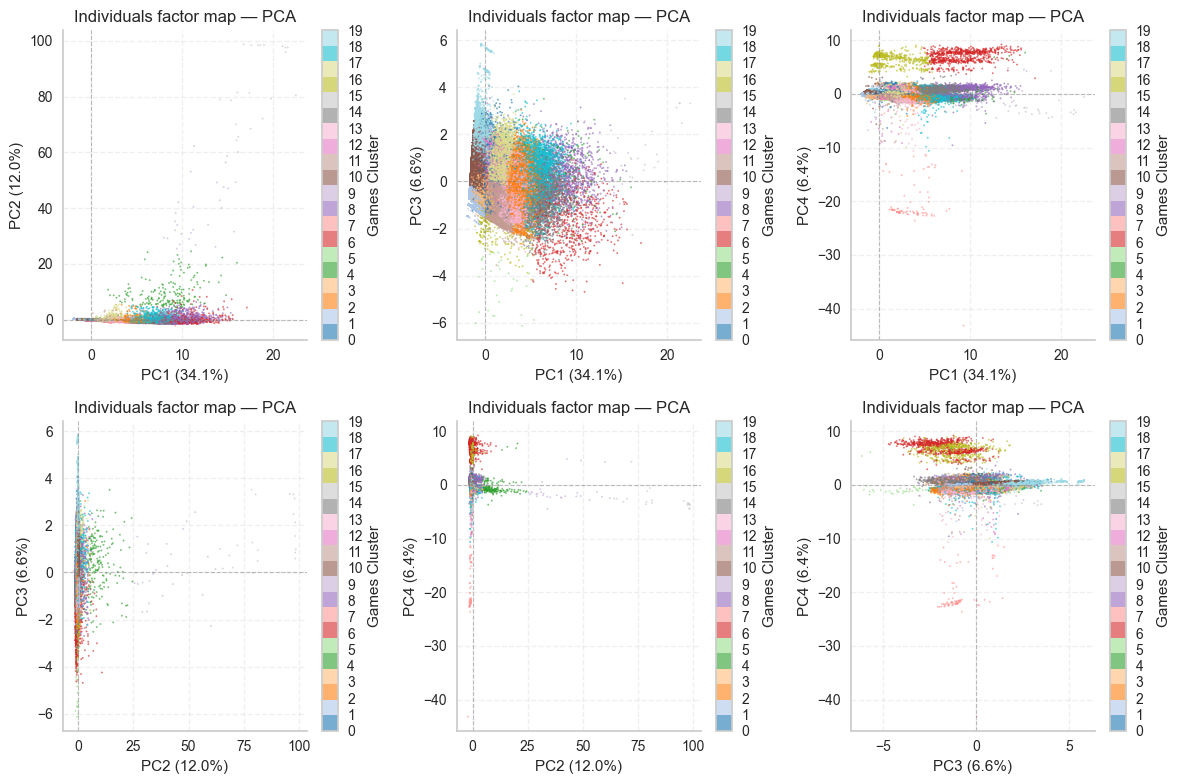

In [86]:
## more Clusters, even though this does not have an optimal silhouette score

K = 20
cmap = plt.get_cmap('tab20',K)

kmeans_games = KMeans(n_clusters=K, init="k-means++", n_init="auto", random_state = 42)
game_clusters[:,2] = kmeans_games.fit_predict(pca_games)

fig, axes = plt.subplots(2,3,figsize = (12,8))

pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]

for idx, (i,j) in enumerate(pairs):

        ax = axes.flatten()[idx]
        sc = ax.scatter(pca_games[:,i],  pca_games[:,j], c = game_clusters[:,2], s = 1, alpha = 0.6, cmap = cmap)

        ax.set_title("Individuals factor map — PCA")
        ax.set_xlabel(f"PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)")
        ax.set_ylabel(f"PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)")
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(True, linestyle="--", alpha=0.3)

        fig.colorbar(sc, ax=ax, ticks=range(K), label= "Games Cluster")

plt.tight_layout()
plt.show()

In [ ]:
### Clusters in a UMAP Projection for PCA Data

### to be executed and calculated during night!


import umap.umap_ as umap 

reducer = umap.UMAP(n_neighbors= 15, min_dist=0.1, random_state=42)

games_pca_umap = reducer.fit_transform(pca_games)
games_scaled_umap = reducer.fit_transform(pca_games_scaled)
games_raw_umap = reducer.fit_transform(raw_games)

umaps = [games_pca_umap, games_scaled_umap, games_raw_umap]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding som

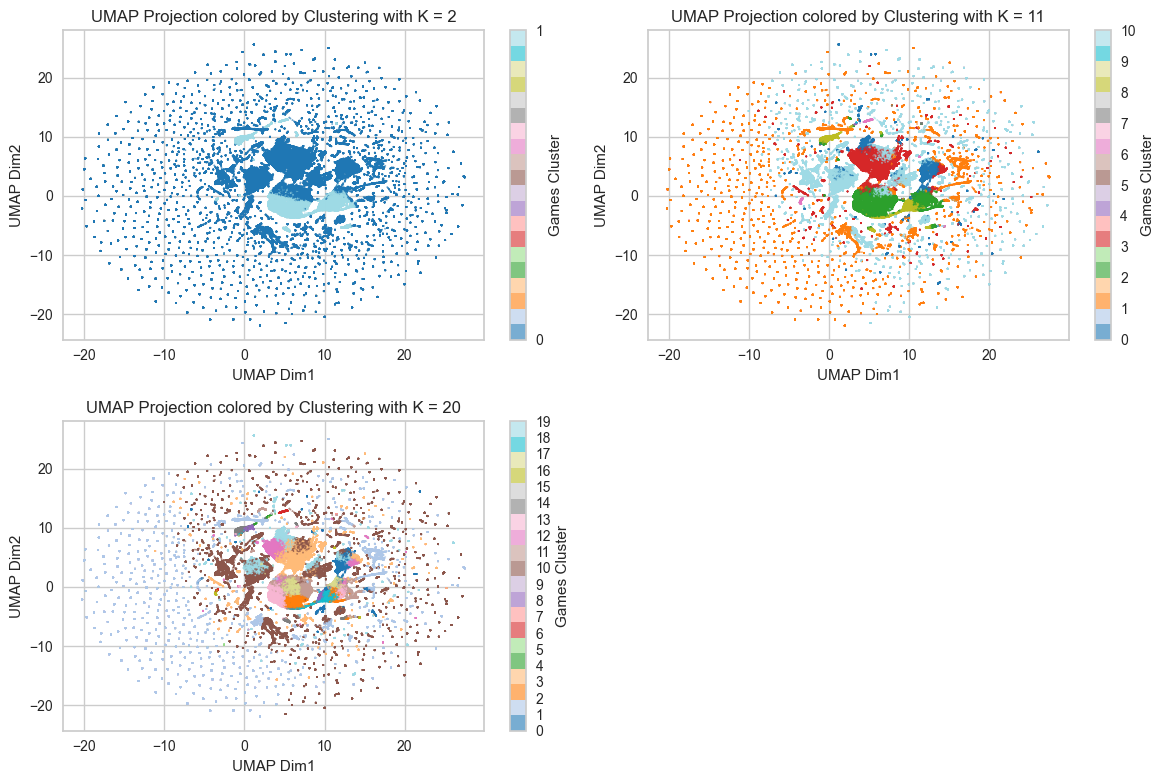

In [ ]:
## Plot the Clusters in the UMAP Projection 

fig, axes = plt.subplots(5,2, figsize=(12,8))

for idx, umap in enumerate(umaps):

    for i in range(3):
        
        index = idx*3 +i
        K = cl_sizes[i]

        cmap = plt.get_cmap('tab20',K)

        ax = axes.flatten()[index]
        sc = ax.scatter(umap[:,0], umap[:,1], c = cluster_partitions[index], s = 1, alpha = 0.6, cmap = cmap)

        ax.set_title(f"UMAP Projection colored by Clustering with K = {K}")
        ax.set_xlabel("UMAP Dim1")
        ax.set_ylabel("UMAP Dim2")

        fig.colorbar(sc, ax=ax, ticks=range(K), label= "Games Cluster")

fig.delaxes(axes.flatten()[9])
plt.tight_layout()
plt.show()

In [64]:
# What type of games are in this one cluster around the origin? for K = 2

df_origin_cluster = df[game_clusters == 0]

df_origin_cluster.describe()


,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Language Count
count,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000,101395.000000
mean,0.464313,0.051975,4.391692,13.990009,0.188944,0.149130,0.019646,17.832931,4.727127,10.903151,10.875645,5.351940,0.157483,5.522481,0.164140,4.905548
std,88.797881,0.917382,13.272598,25.736480,1.863871,3.209825,1.236621,100.813333,17.548087,52.855721,641.562477,62.375246,10.187264,43.110266,10.374085,14.292653
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.490000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.990000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,4.990000,20.000000,0.000000,0.000000,0.000000,14.000000,4.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,28258.000000,21.000000,999.980000,100.000000,103.000000,89.000000,100.000000,11583.000000,1133.000000,5000.000000,197365.000000,13487.000000,2188.000000,3808.000000,2188.000000,103.000000


For K = 2 the games are seperated into groups, with no 

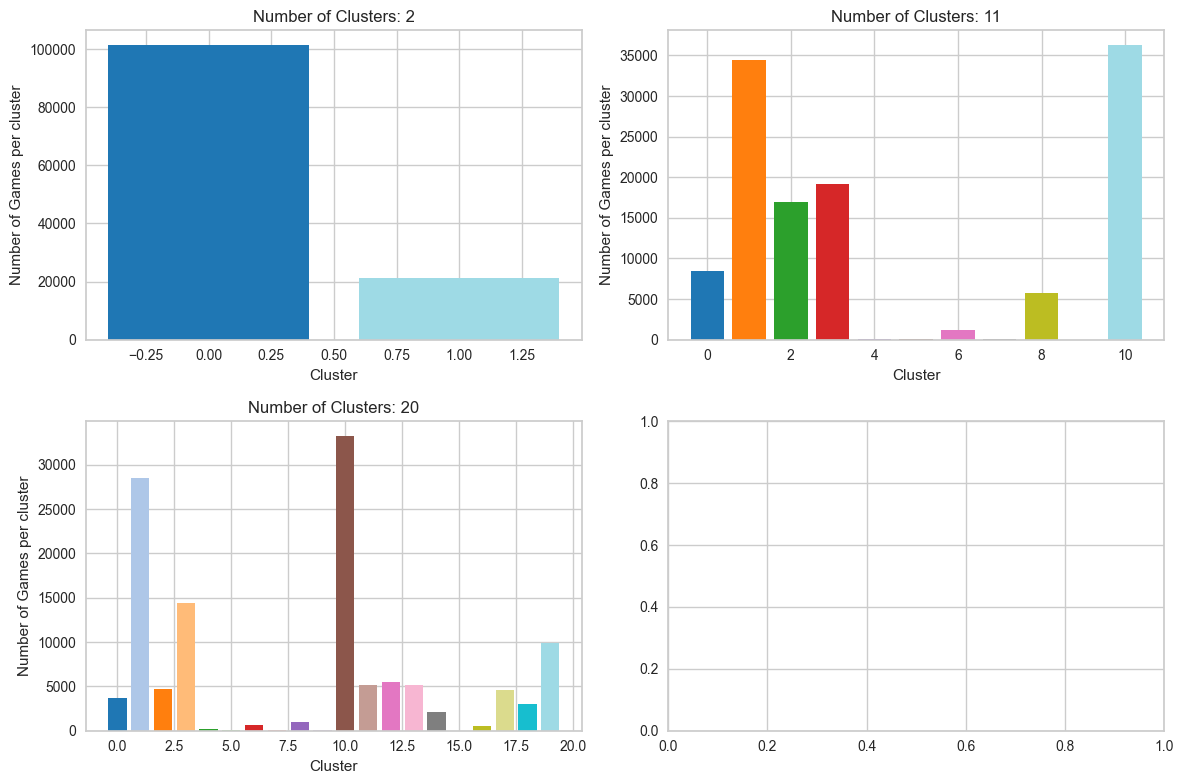

In [148]:
# Number of Games in each cluster depending on 4 different K's

fig, axes = plt.subplots(2,2,figsize = (12,8))

for i in range(3):
    cmap = plt.get_cmap('tab20', cl_sizes[i])
    ax = axes.flatten()[i]
    ax.bar(*np.unique(game_clusters[:,i], return_counts=True), color=cmap.colors)
    ax.set_ylabel("Number of Games per cluster")
    ax.set_xlabel("Cluster")
    ax.set_title(f"Number of Clusters: {cl_sizes[i]}")

plt.tight_layout()
plt.show()



In [140]:


def partition_analysis(data, cluster_partition):

    results = []

    variables = ["Estimated Owners", "Required Age","Price","Year of Release", "Average playtime two weeks" ]

    bool_variables = [(9,12),           ## index 9 is windows index 11 is mac
                      (27,479),         ## thes are the indices for the tags
                      (479,537)]        ## thes are the indices for the categories                 ## pairs of index bounderies for the boolean variables 
    

    for cluster in np.unique(cluster_partition): 

        df_temp = data[cluster_partition == cluster]

        for var in variables: 
            
            if var in ["Year of Release","Required Age"]:
                values = df_temp[var].mode().head(3)

                for rank, value in enumerate(values):
                    
                    results.append({
                        "cluster": cluster,
                        "variable": var,
                        "rank": rank,
                        "value_type": "mode",
                        "value": value
                })
            
            else: 
                value = df_temp[var].mean()

                results.append({
                        "cluster": cluster,
                        "variable": var,
                        "rank": 1,
                        "value_type": "mean",
                        "value": value
                })


        for (i,j) in bool_variables: 

            summed = df_temp.iloc[:,i:j].sum()

            values = summed.sort_values(ascending=False).head(3)

            for rank, (var, value) in enumerate(values.items(), start=1):
                    
                    results.append({
                        "cluster": cluster,
                        "variable": var,
                        "rank": rank,
                        "value_type": "count",
                        "value": value
            })


    summary_clustering_df = pd.DataFrame(results)

    return summary_clustering_df


Umap auch in mehrer Subplots aufteilen 

In [ ]:
### Difference of Kmeans on PCA and on Raw data? 

In [ ]:
## Clustergrafen für spiele mit gleichen Tags/Genres 


# LDA

Pour la LDA nous utilisons des variables qualitatives et quantitatives pour prédire une variable qualitative, c'est la seule méthode de classification supervisée étudiée cette année.

La méthode étant supervisée, il est nécessaire de séparer en train et test le dataset et de choisir une variable à prédire. Ici nous cherchons à prédire l'année de publication du jeu, mais nous pourrions appliquer cette méthode à d'autres variables.

In [ ]:
import prince
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
data_LDA = df3.select_dtypes(include=["number", "int64", "bool", "object"])
data_LDA = data_LDA.drop(columns=["Name","Genres","Tags","Categories","Full audio languages","Supported languages"])

le = LabelEncoder()
data_LDA["Estimated owners"] = le.fit_transform(data_LDA["Estimated owners"].astype(str))
le_year = LabelEncoder()
data_LDA["Year of Release"] = le_year.fit_transform(data_LDA["Year of Release"].astype(str))

target = "Year of Release"
X = data_LDA.drop(columns=target)
Y = data_LDA[target]

train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=0.3, random_state=20)

clf = LDA()
clf.fit(train_x, train_y)

# --- #

train_pred = clf.predict(train_x)
test_pred  = clf.predict(test_x)

train_accuracy = accuracy_score(train_y, train_pred)
test_accuracy  = accuracy_score(test_y, test_pred)

print("--- Linear Discriminant Analysis ---\n")
print("Mapping des classes :", dict(enumerate(le_year.classes_)))
print(f"Train accuracy: {train_accuracy:.2%}")
print(f"Test accuracy:  {test_accuracy:.2%}")
print(' ')

# --- #

print(classification_report(test_y, test_pred))

C:\Users\Jocelin\AppData\Local\Temp\ipykernel_21104\3556904336.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data_LDA = df3.select_dtypes(include=["number", "int64", "bool", "object"])


--- Linear Discriminant Analysis ---

Mapping des classes : {0: '2013', 1: '2014', 2: '2015', 3: '2016', 4: '2017', 5: '2018', 6: '2019', 7: '2020', 8: '2021', 9: '2022', 10: '2023', 11: '2024', 12: '2025'}
Train accuracy: 36.53%
Test accuracy:  34.57%
 
              precision    recall  f1-score   support

           0       0.36      0.61      0.45       588
           1       0.19      0.21      0.20       456
           2       0.24      0.22      0.23       764
           3       0.31      0.35      0.33      1291
           4       0.26      0.21      0.23      1790
           5       0.30      0.29      0.29      2230
           6       0.27      0.25      0.26      2147
           7       0.29      0.20      0.24      2681
           8       0.23      0.19      0.21      3320
           9       0.21      0.10      0.14      3639
          10       0.26      0.16      0.20      4341
          11       0.33      0.41      0.37      6039
          12       0.49      0.72      0.5

# MFA

In [ ]:
import prince

# --- Préparation des données ---

groups = {
    "Performance" : ["Positive", "Negative", "Recommendations", "Peak CCU"],
    "Playtime"    : ["Average playtime forever", "Median playtime forever",
                      "Average playtime two weeks", "Median playtime two weeks"],
    "Metadata"    : ["Price", "DLC count", "Language Count", "Required age", "Achievements"],
    "Plateforme"  : ["Windows", "Mac", "Linux"],
    "Categories"  : [c for c in df3_withOtherLogs.columns if c.startswith("Categories_")],
} 

all_groups = [colonne for group in groups.values() for colonne in group]

data_mfa = df3_withOtherLogs[all_groups].copy()

# Convertir les booléens en int (requis par prince)
bool_cols = data_mfa.select_dtypes(include="bool").columns
data_mfa[bool_cols] = data_mfa[bool_cols].astype(int)

# --- MFA ---
mfa = prince.MFA(n_components=30, random_state=42)
mfa = mfa.fit(data_mfa, groups=groups)

In [ ]:
print(mfa.eigenvalues_summary)
mfa.scree_plot()
print("="*50)
size = data_mfa.columns.size
print(f"Nombre de colonnes : {size}, donc 1/{size} = {1/size}")

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              2.383        12.37%                     12.37%
1              1.067         5.54%                     17.91%
2              0.941         4.89%                     22.80%
3              0.898         4.66%                     27.46%
4              0.853         4.43%                     31.89%
5              0.768         3.99%                     35.88%
6              0.720         3.74%                     39.62%
7              0.666         3.46%                     43.08%
8              0.640         3.32%                     46.40%
9              0.595         3.09%                     49.49%
10             0.549         2.85%                     52.34%
11             0.470         2.44%                     54.78%
12             0.361         1.88%                     56.66%
13             0.343         1.78%                     58.44%
14      

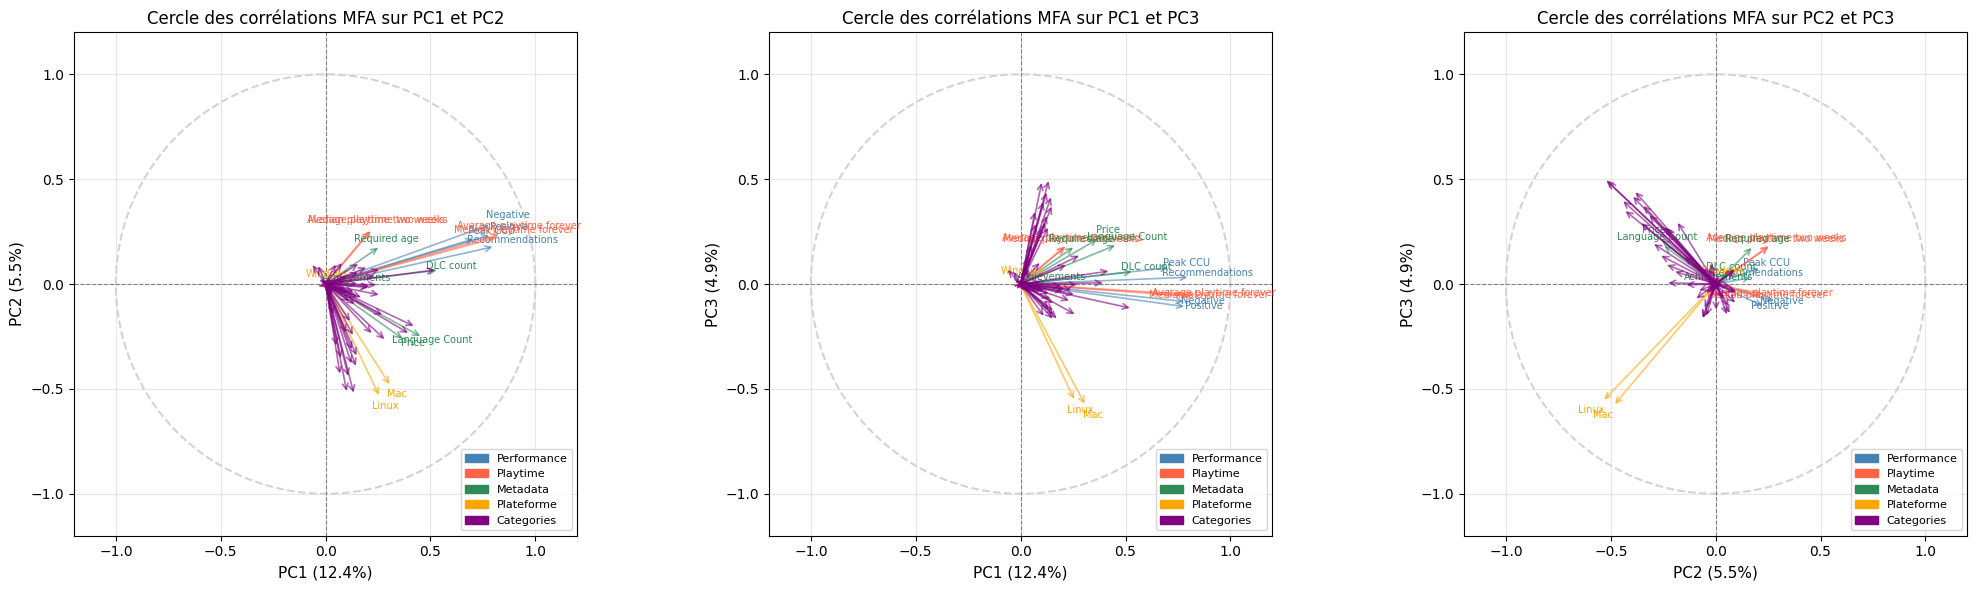

In [ ]:
# Plot fait par Claude
dims = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (dim1, dim2) in zip(axes, dims):
    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), color="lightgrey", lw=1.5, ls="--")
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.axvline(0, color="grey", lw=0.8, ls="--")

    colors = ["steelblue", "tomato", "seagreen", "orange", "purple"]

    for (group_name, group_cols), color in zip(groups.items(), colors):
        for col in group_cols:
            # Corrélation de chaque variable avec les composantes
            x = np.corrcoef(data_mfa[col], mfa.transform(data_mfa).iloc[:, dim1])[0, 1]
            y = np.corrcoef(data_mfa[col], mfa.transform(data_mfa).iloc[:, dim2])[0, 1]
            ax.annotate("", xy=(x, y), xytext=(0, 0),
                        arrowprops=dict(arrowstyle="->", color=color, lw=1.2, alpha=0.6))
            if group_name != "Categories":  # trop de labels sinon
                ax.text(x * 1.1, y * 1.1, col, fontsize=7, color=color, ha="center")

    # Légende groupes
    patches = [mpatches.Patch(color=c, label=g) for g, c in zip(groups.keys(), colors)]
    ax.legend(handles=patches, fontsize=8, loc="lower right")

    var1 = float(mfa.eigenvalues_summary["% of variance"].iloc[dim1].strip("%"))
    var2 = float(mfa.eigenvalues_summary["% of variance"].iloc[dim2].strip("%"))
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(f"PC{dim1+1} ({var1:.1f}%)", fontsize=11)
    ax.set_ylabel(f"PC{dim2+1} ({var2:.1f}%)", fontsize=11)
    ax.set_title(f"Cercle des corrélations MFA sur PC{dim1+1} et PC{dim2+1}", fontsize=12)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def plot_mfa(ax1=0, ax2=1, mfa=mfa, data=data_mfa): # Adaptation du code de famd du tp titanic
    dataset = mfa.transform(data)
    dataset["Year of Release"] = df3_withOtherLogs["Year of Release"].values

    var1 = float(mfa.eigenvalues_summary["% of variance"].iloc[ax1].strip("%"))
    var2 = float(mfa.eigenvalues_summary["% of variance"].iloc[ax2].strip("%"))

    sns.scatterplot(data=dataset, x=ax1, y=ax2,
                    hue="Year of Release", alpha=0.5, s=5)
    plt.xlabel(f"Component {ax1} — {var1:.2f}%")
    plt.ylabel(f"Component {ax2} — {var2:.2f}%")
    plt.grid(True)
    plt.show()

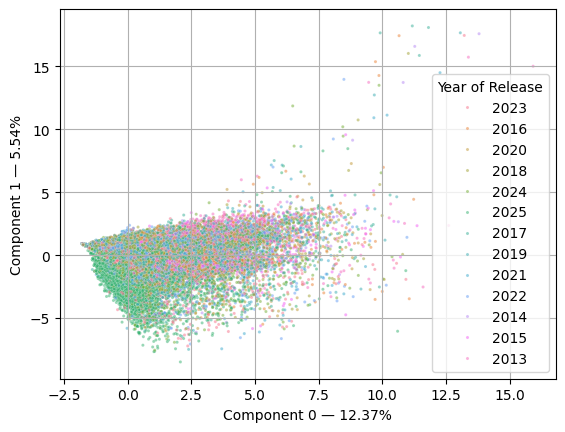

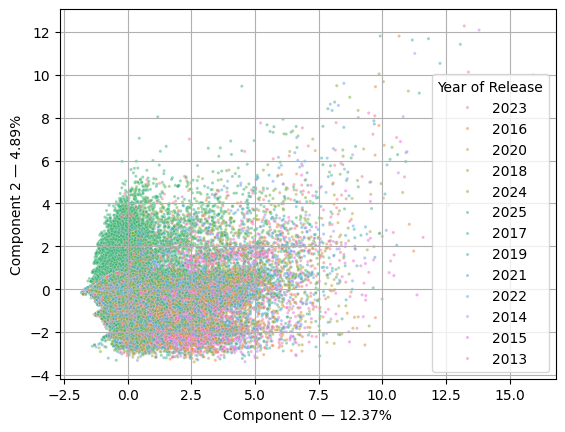

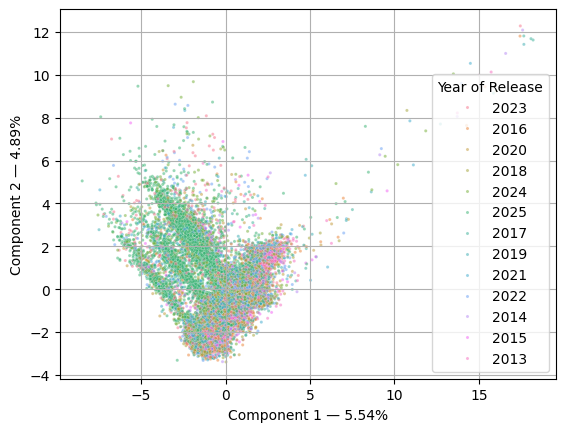

In [ ]:
plot_mfa(0,1)
plot_mfa(0,2)
plot_mfa(1,2)